# 1. Setup

We recommend using GPUs (Runtime > Change runtime type > Hardware accelerator > GPU). Run this cell to clone the DiT GitHub repo and setup PyTorch. You only have to run this once.

In [ ]:
# !git clone https://github.com/facebookresearch/DiT.git
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
os.chdir('./')
print(os.getcwd())
#import os
#os.environ['PYTHONPATH'] = '/env/python:/content/DiT'
# !pip install diffusers timm --upgrade
# DiT imports:
# 由于版本不兼容问题，需要这个代码补丁
# 在导入diffusers之前添加以下代码
import huggingface_hub
if not hasattr(huggingface_hub, 'cached_download'):
    from huggingface_hub import hf_hub_download
    huggingface_hub.cached_download = hf_hub_download

import torch
from torchvision.utils import save_image
from utils.diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from utils.download import find_model
from moyun.moyun_2 import moyun_12channel, moyun_4channel, moyun_12channel_B
from PIL import Image
from IPython.display import display
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("GPU not found. Using CPU instead.")
from utils.config import label2text, text2label
from utils.stroke import get_ch_strokes_tensor
import numpy as np
from torch import Tensor

/mnt/ssd/paper/cvpr2025/moyun2


# Download DiT-XL/2 Models

You can choose between a 512x512 model and a 256x256 model. You can swap-out the LDM VAE, too.

In [ ]:
image_size = 256 #@param [256, 512]
vae_model = "/mnt/ssd/model/image/sd-vae-ft-ema" #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8
# Load ckpt
# moyun_4channel_norepa_3patch = "/home/team/paper/cvpr2025/moyun2/model_eva/001-moyun-4channel/checkpoints/0090000.pt" # 3个维度拼接的
# moyun_L_2_REPA = "/home/team/paper/cvpr2025/moyun2/model/074-test-models-nofeature-12channel/checkpoints/0081000.pt"
# moyun_4channel_norepa = "/home/team/paper/cvpr2025/moyun2/model_eva/004-moyun-4channel/checkpoints/0027000.pt"
# moyun_4channel_repa = "/home/team/paper/cvpr2025/moyun2/model_eva/005-moyun-4channel/checkpoints/0027000.pt"
# moyun_12channel_norepa = "/home/team/paper/cvpr2025/moyun2/model_eva/002-moyun-12channel/checkpoints/0090000.pt"
# moyun_12channel_repa = "/mnt/ssd/paper/cvpr2025/moyun2/model/model_eva/006-moyun-12channel/checkpoints/0090000.pt" 
# moyun_12channel_repa_efont = "/mnt/ssd/paper/cvpr2025/moyun2/model/model_eva/007-moyun-12channel/checkpoints/0072000.pt" 
# moyun_12channel_repa_echar = "/home/team/paper/cvpr2025/moyun2/model_eva/008-moyun-12channel/checkpoints/0090000.pt" 
# moyun_12channel_repa_ecalli = "/home/team/paper/cvpr2025/moyun2/model_eva/009-moyun-12channel/checkpoints/0090000.pt" 
# moyun_12channel_repa_full = "/mnt/ssd/paper/cvpr2025/moyun2/model/model_train_ful/007-moyun-12channel-B/checkpoints/0144000.pt"

ckpt_path = "/mnt/ssd/paper/cvpr2025/moyun2/model/model_train_ful"
ckpt_num = "0108000"
models = {
    "1" : os.path.join(ckpt_path, "001-moyun-12channel", f"checkpoints/{ckpt_num}.pt"), #   12 channel REPA 0.08 0.08 0.16
    "2" : os.path.join(ckpt_path, "002-moyun-12channel", f"checkpoints/{ckpt_num}.pt"), #   12 channel REPA 0    0    0
    "3" : os.path.join(ckpt_path, "003-moyun-4channel",  f"checkpoints/{ckpt_num}.pt"), #   4  channel REPA 0    0    0
    "4" : os.path.join(ckpt_path, "004-moyun-12channel", f"checkpoints/{ckpt_num}.pt"), #   12 channel REPA 0.08 0.08 0.16
    "5" : os.path.join(ckpt_path, "005-moyun-12channel-B", f"checkpoints/{ckpt_num}.pt"), # 12 channel REPA 0.08 0.08 0.08 B
    "6" : os.path.join(ckpt_path, "006-moyun-12channel-B", f"checkpoints/{ckpt_num}.pt"), # 12 channel REPA 0.08 0.08 0.16 B
    "7" : os.path.join(ckpt_path, "007-moyun-12channel-B", f"checkpoints/{ckpt_num}.pt"), # 12 channel REPA 0.08 0.16 0.08 B
    "8" : os.path.join(ckpt_path, "008-moyun-12channel-B", f"checkpoints/{ckpt_num}.pt"), # 12 channel REPA 0.16 0.08 0.08 B
}
model_name =  "1"
print(f"{model_name=}, {ckpt_num=}")
test_models_str = models[model_name]
state_dict = find_model(test_models_str)

# set channel
use_12channel = "12channel" in test_models_str
use_B = "B" in test_models_str
# Load model:
if use_12channel:
    if use_B:
        model = moyun_12channel_B(input_size=latent_size,if_rope = False, if_rope_residual = False, device = device, num_classes=4793).to(device)
    else:
        model = moyun_12channel(input_size=latent_size,if_rope = False, if_rope_residual = False, device = device, num_classes=4793).to(device)
else:
    model = moyun_4channel(input_size=latent_size,if_rope = False, if_rope_residual = False, device = device, num_classes=4793).to(device)
model.load_state_dict(state_dict)
model.eval() # important!
vae = AutoencoderKL.from_pretrained(vae_model).to(device)

model_name='1', ckpt_num='0108000'


In [ ]:
def load_features(label):
    root_path = "/home/team/paper/cvpr2025/moyun2/dataset/256png_SAM_feature"
    name_path = os.path.join(root_path, "name", f"{label[0]}.npy")
    ziti_path = os.path.join(root_path, "ziti", f"{label[1]}.npy")
    zi_path = os.path.join(root_path, "zi", f"{label[2]}.npy")
    calligrapher = np.load(name_path)
    font = np.load(ziti_path)
    charactor = np.load(zi_path)
    print(calligrapher.shape, font.shape, charactor.shape)
    
    label = np.concatenate((calligrapher[0], font, charactor),0)
    return label

In [ ]:
def get_condition(calligraphy):
    class_labels = [text2label(*item) for item in calligraphy]
    # class_labels = [load_features(item) for item in calligraphy]
    stroke = [get_ch_strokes_tensor(item[2]).numpy() for item in calligraphy]
    stroke = np.array(stroke)
    return class_labels, stroke

# 2. Sample from Pre-trained DiT Models

You can customize several sampling options. For the full list of ImageNet classes, [check out this](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).

seed=2
torch.Size([1, 64, 64])


  0%|          | 0/1000 [00:00<?, ?it/s]

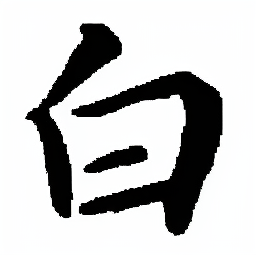

In [ ]:
# Set user inputs:
import random
seed = random.randint(1,65536) #@param {type:"number"}
seed = 2
print(f'{seed=}')
torch.manual_seed(seed)
num_sampling_steps = 1000 #@param {type:"slider", min:0, max:1000, step:1}
cfg_scale = 2.5 #@param {type:"slider", min:1, max:10, step:0.1}
samples_per_row = 10 #@param {type:"number"}

class_labels, stroke = get_condition((
    # ('颜真卿', '楷书', '既'),
    # ('颜真卿', '楷书', '如'),
    # ('王羲之', '楷书', '何'),
    # ('颜真卿', '楷书', '阳'),
    # ('赵孟頫', '楷书', '先'),
    # ('赵孟頫', '楷书', '立'),
    # ('赵孟頫', '楷书', '将'),
    # ('王羲之', '楷书', '高'),
    # ('颜真卿', '楷书', '立'),
    # ('王羲之', '草书', '高'),
))
class_labels, stroke = get_condition((
    # ('颜真卿', '楷书', '华'),
    # ('颜真卿', '楷书', '东'),
    # ('颜真卿', '楷书', '师'),
    # ('颜真卿', '楷书', '范'),
    # ('颜真卿', '楷书', '大'),
    # ('颜真卿', '楷书', '学'),
))

"基于扩散模型的高可控中文书法生成方法研究"
class_labels, stroke = get_condition((
    ('王羲之', '楷书', '基'),
    ('王羲之', '楷书', '于'),
    ('王羲之', '楷书', '扩'),
    ('王羲之', '楷书', '散'),
    ('王羲之', '楷书', '模'),
    ('王羲之', '楷书', '型'),
    ('王羲之', '楷书', '的'),
    ('王羲之', '楷书', '高'),
    ('王羲之', '楷书', '可'),
    ('王羲之', '楷书', '控'),
    ('王羲之', '楷书', '冲'),
    ('王羲之', '楷书', '文'),
    ('王羲之', '楷书', '书'),
    # ('王羲之', '楷书', '法'),
    # ('王羲之', '楷书', '生'),
    # ('王羲之', '楷书', '成'),
    # ('王羲之', '楷书', '方'),
    # ('王羲之', '楷书', '法'),
    # ('王羲之', '楷书', '研'),
    # ('王羲之', '楷书', '究'),
))
# class_labels, stroke = get_condition(
#     (('赵孟頫', '楷书', '申'),)*4
#     +
#     (('赵孟頫', '行书', '词'),)*4
# )



# Create diffusion object:
diffusion = create_diffusion(str(num_sampling_steps))

# Create sampling noise:
n = len(class_labels)
z = torch.randn(n, 12 if use_12channel else 4, latent_size, latent_size, device=device)

y = torch.tensor(class_labels, device=device)
stroke = torch.tensor(stroke, device=device)
# Setup classifier-free guidance:
z = torch.cat([z, z], 0)
y_null = torch.tensor([(4793,4793,4793)] * n, device=device)
y = torch.cat([y, y_null], 0)
print(stroke.shape)
stroke_null = torch.full((n, 64, 64), 1000, device=device)
stroke = torch.cat([stroke,stroke_null], 0)
model_kwargs = dict(y=y, stroke = stroke, cfg_scale=cfg_scale)

# Sample images:
samples = diffusion.p_sample_loop(
    model.forward_with_cfg, z.shape, z, clip_denoised=False, 
    model_kwargs=model_kwargs, progress=True, device=device
)
# print(samples)
samples, _ = samples.chunk(2, dim=0)  # Remove null class samples
samples = samples[:,0:4,:,:]
white_sigle = torch.load("./white.pt").to(device)
white_x = white_sigle.repeat(samples.shape[0],1,1,1)
# samples = torch.randn(n, 4, latent_size, latent_size, device=device)
# samples += white_x
samples = vae.decode(samples / 0.18215).sample


# Save and display images:
save_image(samples, "./sample_250.png", nrow=int(samples_per_row), 
           normalize=True, value_range=(-1, 1))
samples = Image.open("./sample_250.png")
display(samples)
# samples_first_channel = samples[:, 2:3, :, :]  # 仅保留第一个通道

# # 保存为单通道图像
# save_image(samples_first_channel, "/home/lky/moyun/save/sample_250_first_channel.png", 
#            nrow=int(samples_per_row), normalize=True, value_range=(-1, 1))

# # 加载并显示单通道图像
# samples = Image.open("/home/lky/moyun/save/sample_250_first_channel.png").convert('L')  # 'L' 表示灰度模式
# display(samples)

In [ ]:
# 重复生成

for _ in range(0):
    raw_label = (('文征明', '楷书', '都'),)
    class_labels, stroke = get_condition(raw_label)

    seed = random.randint(1,65536) #@param {type:"number"}
    torch.manual_seed(seed)

    # Create diffusion object:
    diffusion = create_diffusion(str(num_sampling_steps))

    # Create sampling noise:
    n = len(class_labels)
    z = torch.randn(n, 12 if use_12channel else 4, latent_size, latent_size, device=device)

    y = torch.tensor(class_labels, device=device)
    stroke = torch.tensor(stroke, device=device)
    # Setup classifier-free guidance:
    z = torch.cat([z, z], 0)
    y_null = torch.tensor([(4793,4793,4793)] * n, device=device)
    y = torch.cat([y, y_null], 0)
    # print(stroke.shape)
    stroke_null = torch.full((n, 64, 64), 1000, device=device)
    stroke = torch.cat([stroke,stroke_null], 0)
    model_kwargs = dict(y=y, stroke = stroke, cfg_scale=cfg_scale)

    # Sample images:
    samples = diffusion.p_sample_loop(
        model.forward_with_cfg, z.shape, z, clip_denoised=False, 
        model_kwargs=model_kwargs, progress=True, device=device
    )
    # print(samples)
    samples, _ = samples.chunk(2, dim=0)  # Remove null class samples
    samples = samples[:,0:4,:,:]
    white_sigle = torch.load("./white.pt").to(device)
    white_x = white_sigle.repeat(samples.shape[0],1,1,1)
    samples = vae.decode(samples / 0.18215).sample


    # Save and display images:
    os.makedirs(f"./out_imgs/{raw_label[0][0]}_{raw_label[0][1]}_{raw_label[0][2]}", exist_ok=True)
    save_image(samples, f"./out_imgs/{raw_label[0][0]}_{raw_label[0][1]}_{raw_label[0][2]}/{raw_label[0][0]}_{raw_label[0][1]}_{raw_label[0][2]}_{seed}.png", nrow=int(samples_per_row), 
            normalize=True, value_range=(-1, 1))

In [ ]:
print("finish")

finish


In [ ]:
from torchinfo import summary
t = torch.Tensor([1] * n).long().to('cuda:0')  # 时间步
x = torch.randn(n, 12, 32, 32).to('cuda:0')  # 输入图像
y = torch.Tensor([(0, 0, 0)] * n).long().to('cuda:0')  # 类别标签
stroke = [get_ch_strokes_tensor('既').numpy()] * 8
stroke = np.array(stroke)
stroke = Tensor(stroke).to('cuda:0')
summary(model,input_data=[x, t, y, stroke],col_names=["input_size",
                       "output_size",
                       "num_params",
                       "trainable",
                       "kernel_size",
                       "mult_adds"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable                 Kernel Shape              Mult-Adds
Moyun                                    [1, 12, 32, 32]           [1, 24, 32, 32]           262,144                   Partial                   --                        --
├─PatchEmbed: 1-1                        [1, 12, 32, 32]           [1, 256, 1024]            --                        True                      --                        --
│    └─Conv2d: 2-1                       [1, 12, 32, 32]           [1, 1024, 16, 16]         50,176                    True                      [2, 2]                    12,845,056
│    └─Identity: 2-2                     [1, 256, 1024]            [1, 256, 1024]            --                        --                        --                        --
├─TimestepEmbedder: 1-2                  [1]                       [1, 1024]                 --                    